# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [44]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np

In [45]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv') 

In [46]:
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [47]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [48]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [49]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [50]:
 plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [51]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [52]:
 usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [53]:
# cantidad de nulos para users

print(users.isnull().sum())
print(users.isnull().mean()*100)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [54]:
# cantidad de nulos para usage
print(usage.isnull().sum())
print(usage.isnull().mean()*100)


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Análisis

USERS:

City: para la columna city se encontró un porcentaje de nulos de 11.73. Lo que indica que son valores que deben analizar para definir el procedimiento con ellos.
churn_date: Se encontró un porcentaje de 88.35 nulos, es decir, solo el 11.65 son valores nulos, por lo tanto, esta columna no representa datos significativos para el análisis, siendo mejor eliminarla o ignorarla en el filtro de análisis de insights.

USAGE:

date: Esta columna tiene un porcentaje bajo de nulos, de tan solo 0.125 %. Por lo tanto, puede ser imputada, ya que no afecta directamente el resultado de los datos.
duration y length: Son valores que de entrada ya nos están dando información clave para el análisis, es decir, el 55.19 % de las interacciones son por medio de llamadas, mientras el 44.740 % son mensajes de texto. En este caso tocaría filtrar la base de datos sin imputar, ya que son dos métricas que se deben analizar de manera distinta.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [55]:

# explorar columnas numéricas de users

col_numerics_users = users[['age', 'user_id']]
col_numerics_users.describe()



,age,user_id
count,4000.000000,4000.000000
mean,33.739750,11999.500000
std,123.232257,1154.844867
min,-999.000000,10000.000000
25%,32.000000,10999.750000
50%,47.000000,11999.500000
75%,63.000000,12999.250000
max,79.000000,13999.000000


- La columna `user_id` La cantidad de users_id es correcta, No hay valores negativos, la media y mediana es muy similar 
- La columna `age`  No hay valores nulos, la media y la mediana tiene una variación de 14 años y tiene valore negativos que hay que revisar, el valor máximo es un numero posible

In [56]:
# explorar columnas numéricas de usage
col_numerics_usage = usage[['id', 'user_id', 'duration', 'length']]
col_numerics_usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`  no tienen valores nulos,   a pesar, de que ambos sean IDs no se refiere a lo mismo, por lo tanto, es normal que los valores sean distintos, cabe aclarar que no hay valores negativos. 
- Las columnas  `duration` y  `length` como ya se analizó anteriormente, son columnas muy diferentes una es vália para texto y otras para llamadas, al parecer ambas tienen ouliers, pero no tienen valores negaativos que deban analizarse a profundidad. 

In [57]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city`  contiene valores nulos con 7 valores únicos, siendo Bogotá la moda 
- La columna `plan`  Sin valores nulos, sólo dos valóres únicos (claves con data set plans), con el 64.86%  para el plan básico

In [58]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` sin valores nulos, 2 valores únicos siendo text 55.23 %  más frecuente 


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?

Columas a revisar: 

- age:  valores negativos, lo cual modifica los datos, por lo tanto, se debe imputar 
- Duration y Length: valores que deben modificarse por NAN o separar por tipo para crear una nueva agrupación 
- City: hay datos faltantes  imputar con moda 
- 

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [59]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] =  pd.to_datetime(users['reg_date'] , errors = 'coerce', utc= True )
users['reg_date'].dtype

datetime64[ns, UTC]

In [60]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'] , errors = 'coerce', utc= True )
usage['date'].dtype

datetime64[ns, UTC]

In [61]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

En `reg_date`,  Se tiene un rango de años de 2022 al 2026

In [62]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, ... sólo se tiene registros del año 2024  .  
Basaremos el análisis en estas fechas. --   2024 para ambos data frames

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

como se requiere un análisis completo se hace inecesario analizar años que no estén presentes en ambos dataframes, por lo tanto es más recomendable usar año 2024

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [63]:

# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
sentinels= [-999]
users['age'] = users['age'].replace(sentinels,age_mediana )
# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [64]:
# Reemplazar ? por NA en city
invalid_city = ['?']
users['city'] = users['city'].replace(invalid_city, np.nan)

# Verificar cambios
users['city'].isna().sum()

565

In [65]:

# Marcar fechas futuras como NA para reg_date
users['reg_date']= users['reg_date'].where(
    users['reg_date'].dt.year <= 2024)

# Verificar cambios
users['reg_date'].isna().sum() 


40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [66]:

# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending = False)


type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [67]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending = False)


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`  

Tal como se sospechó desde el principio la falta de datos en estas columnas son MAR, dependen exclusivamente de  la columna Type. Por eso se establecen como nulos. revisé y no hay valores que no sean NAN o números, por lo tanto no hay que cambiar nada. 


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [68]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({ 'is_text': 'sum', 'is_call' : 'sum' , 'duration': 'sum' }). reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [69]:

# Renombrar columnas
usage_agg.columns =['user_id', 'total_text', 'total_call', 'total_call_minute']
# observar resultado
usage_agg.head(3)


,user_id,total_text,total_call,total_call_minute
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [70]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_text,total_call,total_call_minute
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [71]:
# Resumen estadístico de las columnas numéricas

numeric_cols=  ['age', 'total_text', 'total_call', 'total_call_minute']
user_profile[numeric_cols].describe()


,age,total_text,total_call,total_call_minute
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.122250,5.524381,4.478120,23.317054
std,17.690408,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [72]:
# Distribución porcentual del tipo de plan

print(user_profile['plan'].value_counts(normalize=True) * 100)
user_profile['city'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


Bogotá      23.522562
CDMX        21.251820
Medellín    17.933042
GDL         13.100437
Cali        12.343523
MTY         11.848617
Name: city, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

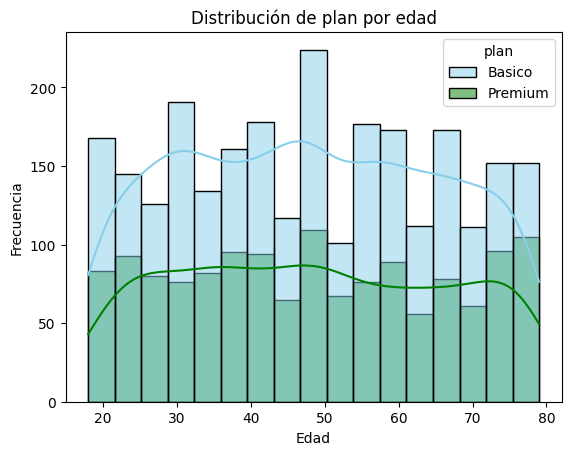

In [73]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x= 'age', hue='plan', kde= True,palette=['skyblue','green']  )
plt.title('Distribución de plan por edad')
plt.xlabel ('Edad')
plt.ylabel ('Frecuencia')
plt.show()

💡Insights: 
- En general la distribución es uniforme, para ambos planes sin muchas variaciones ni sesgos 
- El tipo de Cliente mas frecuente para ambos planes es  entre los  47 y 50 años
- Ambos planes tienen clientes frecuentes entre los 18 y 80 años
- El plan básico tiene mayores números de ventas
- Al parecer, la edad no influye en el tipo de plan a elegir por los usuarios 

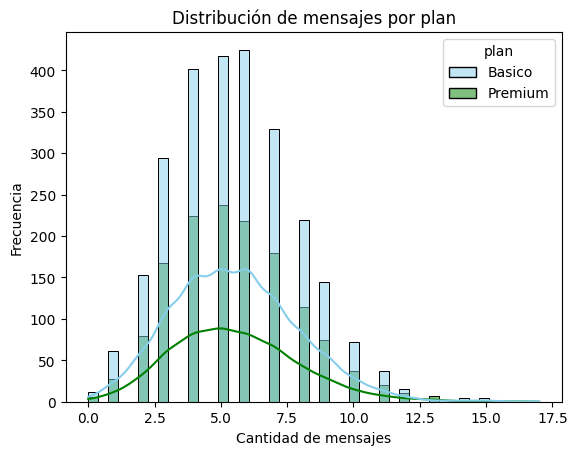

In [74]:
# Histograma para visualizar la cant_mensajes


sns.histplot(data=user_profile, x= 'total_text', hue='plan', kde= True,palette=['skyblue','green']  )
plt.title('Distribución de mensajes por plan')
plt.xlabel ('Cantidad de mensajes')
plt.ylabel ('Frecuencia')
plt.show()



💡Insights: 
- El diagrama tiene una distribución a la derecha
- Los usuarios del plan Básico envían mayor cantidad de mesajes que los del plan premium, sin embargo, hay varios clienes premium que envían gran cantidad de mesajes de texto
- La mayoría de los usuarios envía  entre 30 y 80 mensajes 

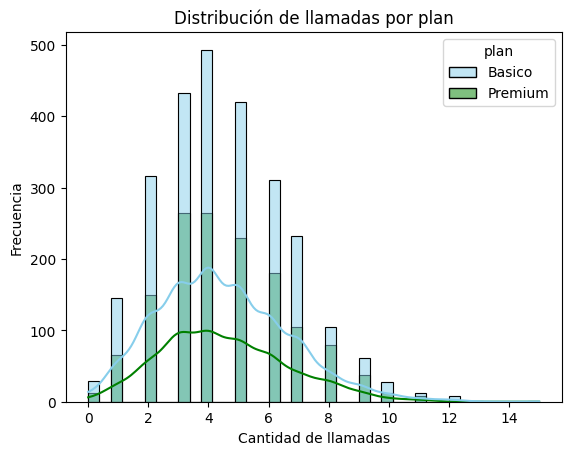

In [75]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x= 'total_call', hue='plan', kde= True,palette=['skyblue','green']  )
plt.title('Distribución de llamadas por plan')
plt.xlabel ('Cantidad de llamadas')
plt.ylabel ('Frecuencia')
plt.show()


💡Insights: 
- Distribución ligeramenre a la derecha
- En este caso,  los usuarios del plan básico hacen más llamadas que en el plan Premium
- La mayoría de usuarios realiza entre 3 a  7 llamadas
- 

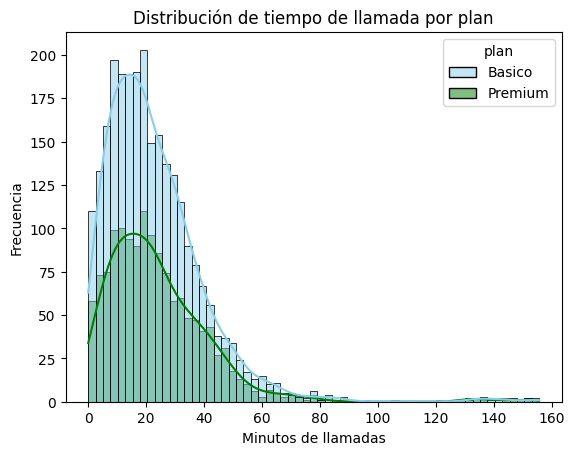

In [76]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(data=user_profile, x= 'total_call_minute', hue='plan', kde= True,palette=['skyblue','green']  )
plt.title('Distribución de tiempo de llamada por plan')
plt.xlabel ('Minutos de llamadas')
plt.ylabel ('Frecuencia')
plt.show()


💡Insights: 
- Sesgo evidente a la derecha
- Los usuarios dell plan básico tienen más minutos por llamada
- El rango de llamadas más frecuente es de 10  a  30 minutos 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

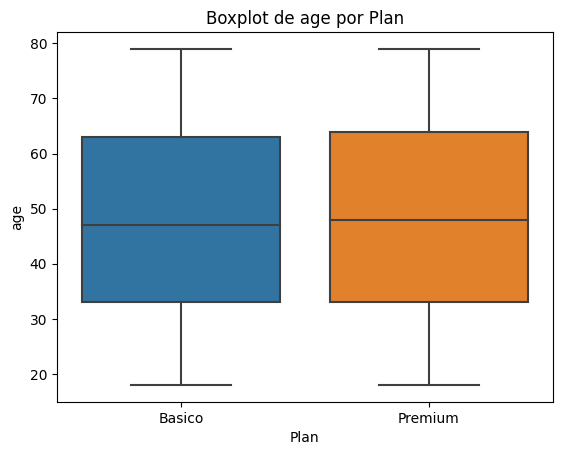

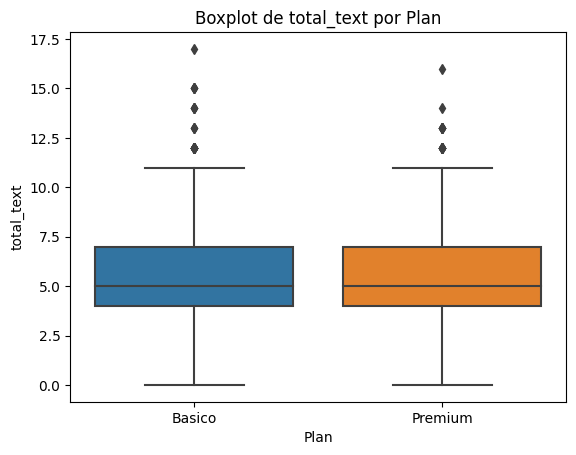

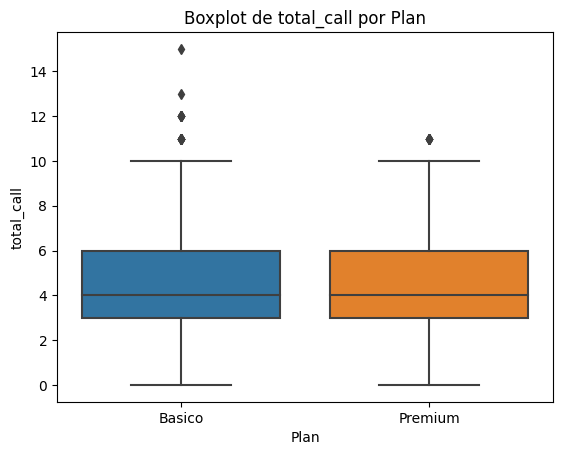

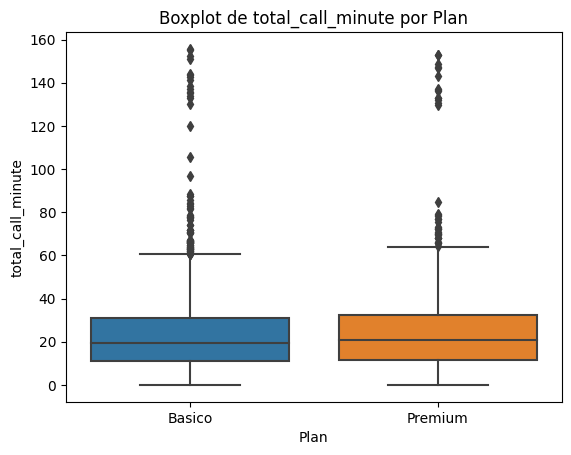

In [77]:

# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'total_text', 'total_call', 'total_call_minute']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x='plan', y=col)
    plt.title(f'Boxplot de {col} por Plan')
    plt.xlabel('Plan')
    plt.ylabel(col)
    plt.show()


💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta  outliers 1  punto más en el plan básico 
- cant_llamadas:  Presenta  outliers 3  puntos más en el plan básico  
- cant_minutos_llamada:  Presenta  muchos outliers   

In [78]:
# Calcular límites con el método IQR
columnas_limites = [ 'total_text', 'total_call', 'total_call_minute']

for col in  columnas_limites:
    q1= user_profile[col].quantile(0.25)
    q3= user_profile[col].quantile(0.75)
    iqr = q3-q1
    lower= q1 - 1.5* iqr
    upper = q3 + 1.5* iqr
    print(f"{col}:")
    print(f"  Límite superior: {upper}")



total_text:
  Límite superior: 11.5
total_call:
  Límite superior: 10.5
total_call_minute:
  Límite superior: 61.8575


In [79]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,total_text,total_call,total_call_minute
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?  Es mejor mantener los outlier, ya que, el limite es muy cerca al valor máximo, entonccesno habría un sesgo
- cant_llamadas: mantener o no outliers, porqué? Se decide conservar outlier al igual que en  cant_mensajes
- cant_minutos_llamada: mantener o no outliers, porqué?  Es mejor hacer modificaciones por que el límite está muy por encima   61.8575 %  entonces pueed sesgar la información

In [80]:

upper = user_profile['total_call_minute'].quantile(0.95)
user_profile['total_call_minute'] = user_profile['total_call_minute'].clip(upper=upper)
user_profile['total_call_minute'].max()

52.083

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [81]:


# Crear columna grupo_uso
def classify_segment(row):
    text = row['total_text']
    call= row['total_call']
    
    if(call < 5) and (text < 5):
        return 'Bajo uso'
    elif (call < 10) and (text < 10):
        return  'Uso medio'
    else:
        return  'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(classify_segment, axis = 1 )



In [82]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_text,total_call,total_call_minute,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [83]:
# Crear columna grupo_edad
def classify_age(row):
    age = row['age']
    
    if age < 30:
        return 'Joven'
    elif age < 60:
        return  'Adulto'
    else:
        return  'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(classify_age, axis = 1 )


In [84]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,total_text,total_call,total_call_minute,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00+00:00,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619+00:00,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239+00:00,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858+00:00,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478+00:00,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

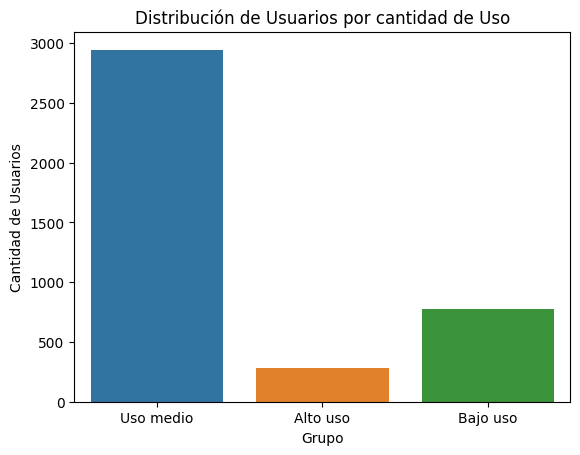

In [85]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Distribución de Usuarios por cantidad de Uso')
plt.xlabel('Grupo')
plt.ylabel('Cantidad de Usuarios')
plt.show()
plt.show()

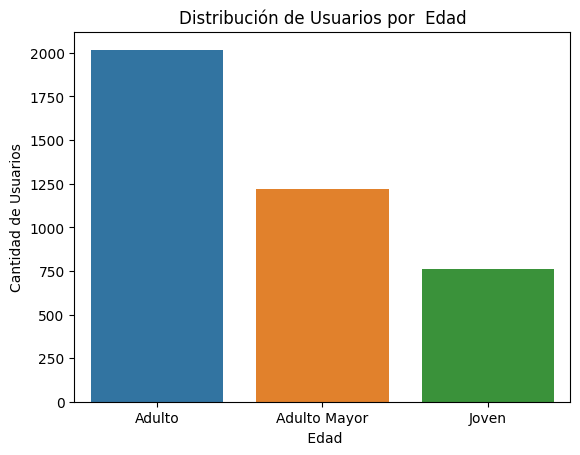

In [86]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Distribución de Usuarios por  Edad')
plt.xlabel(' Edad')
plt.ylabel('Cantidad de Usuarios')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

Datos: 
Inicimente el dataSet Users presentaba un porcentaje de  11.7%  de datos faltante para la columna City. En el mismo data set la columna churn_date    presentaba un porcentaje de  88.35 en valores nulos lo que no lo hacía una fuente confiable para añadir en el dataset final. Iguallmente, se encontraron varios valores atipicos que uno se winzorizaron (total_call_minute) y los demás se dejaro por que no representaban riesgo de sesgo. 

Segmentos: 
Se segmentaron los tipos de planes por edad y uso, se encontró que a mayoría de clientes tiene un uso medio del plan. Los usuarios de alto uso representan una proporción pequeña, pero son estratégicamente importantes debido a su mayor nivel de consumo. A su vez, so adultos, es decir, personas entre 30 y 60 son el grupo más grandes eguido por adultos mayores y, en menor proporción, jóvenes. Esto indica que el mercado principal de la compañía está compuesto por usuarios en edad productiva 

Patrones de outliers:
Se identificó, varios outlier en mesajes y llamadas que se comportan como datos reales, al igual, se identificó mayores outliers en minutos de llamadas que pueden tratarse de caso ocasionales reales sin embargo, se dcidió intervenir para no modificar la calidad del data set. 

Recomendaciones: 
Se recomienda diseñar un plan premium orientado a usuarios de alto consumo, que ofrezca mayores beneficios como minutos adicionales, llamadas ilimitadas y descuentos por permanencia o nivel de uso. Este plan no solo permitiría fidelizar a los usuarios más intensivos, sino que también funcionaría como un objetivo atractivo para los usuarios de consumo medio, incentivando su migración hacia planes de mayor valor

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores faltantes en la columna City  11.7%
- 88.35%  de valores nulos en churn_date
- Valores atípicos en las variables total_call, total_text y total_call_minute 


🔍 **Segmentos por Edad**
- Adultos:  Entre 30y 60 años  grupo dominante 
- Adultos mayores :   60 Años en adelante
- Jóvenes   menores a 30 Años menor presencia


📊 **Segmentos por Nivel de Uso**
- Uso medio Mayoría de usuarios
- Bajo uso Segundo grupo
- Alto uso minoría


➡️ Esto sugiere que El cliente típico de es un usuario adulto con nivel de uso medio. Esto representa una gran oportunidad para implementar estrategias de crecimiento, enfocadas en convertir usuarios de consumo medio en usuarios de alto consumo, aumentando así el valor por cliente.

💡 **Recomendaciones**
- Diseñar un plan premium con mayores beneficios (más minutos, llamadas ilimitadas, descuentos por fidelización) enfocado en usuarios de alto consumo
- Utilizar este plan como objetivo aspiracional para usuarios de uso medio, incentivando su migración
- Optimizar la estructura de los planes actuales para alinear mejor beneficios con patrones reales de us 

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`